In [312]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [313]:
df = pd.read_csv('Titanic-Dataset.csv')

In [314]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [315]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [316]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [317]:
df.isna().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [318]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [319]:
df.duplicated().sum()

np.int64(0)

In [320]:
df[df['Embarked'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [321]:
from scipy.stats import mode

In [322]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

<Axes: title={'center': 'People Survived Compared To The Embarked Class'}, xlabel='Embarked', ylabel='count'>

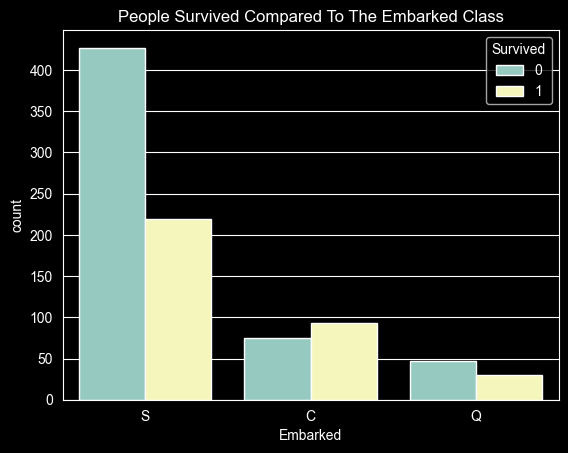

In [323]:
plt.title("People Survived Compared To The Embarked Class")
sns.countplot(data=df,x=df['Embarked'],hue=df['Survived'])

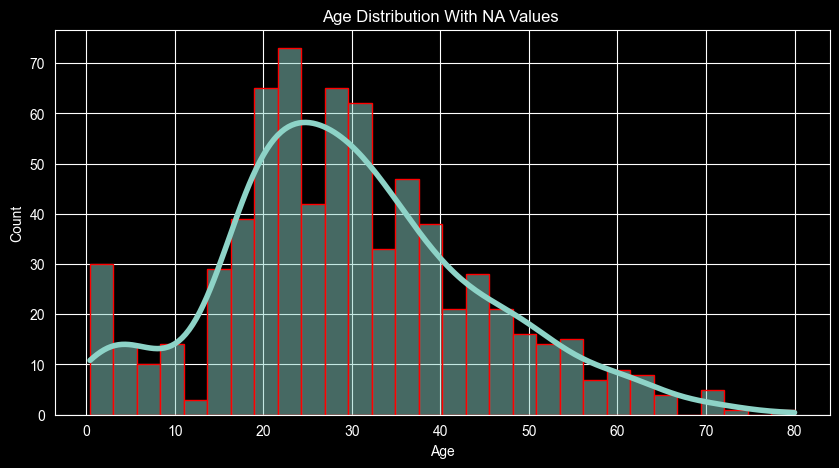

In [324]:
plt.figure(figsize=(10,5))
plt.title("Age Distribution With NA Values ")
sns.histplot(
    data=df,
    x='Age',
    kde=True,
    bins=30,
    edgecolor='red',
    line_kws=dict(color='red', linewidth=4)
);


In [325]:
df['Age'].mean()

np.float64(29.69911764705882)

In [326]:
"""For The PARCH OF 0 the NAN Values will be filled Based on the average Age"""

'For The PARCH OF 0 the NAN Values will be filled Based on the average Age'

In [327]:
df['Age'] = df.groupby(['Pclass','Sex'])['Age']\
              .transform(lambda x: x.fillna(x.median()))

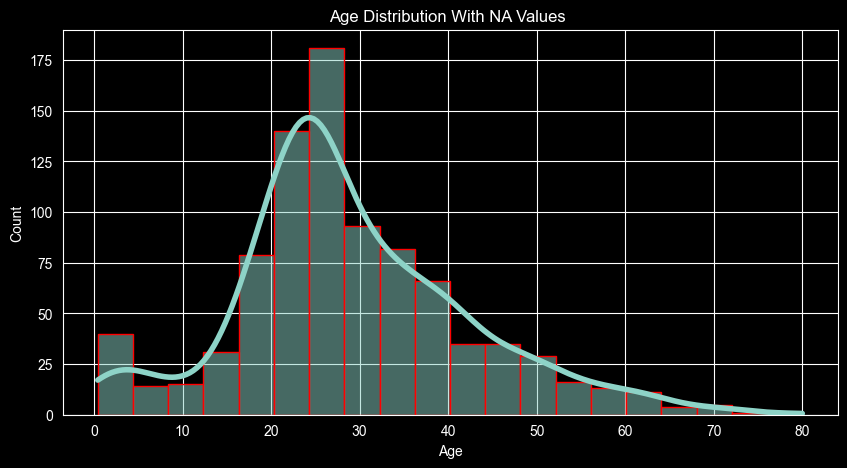

In [328]:
plt.figure(figsize=(10,5))
plt.title("Age Distribution With NA Values ")
sns.histplot(
    data=df,
    x='Age',
    kde=True,
    bins=20,
    edgecolor='red',
    line_kws=dict(color='red', linewidth=4)
);

In [329]:
df['Cabin'].isna().mean() * 100

np.float64(77.10437710437711)

In [330]:
df.drop('Cabin',axis=1,inplace=True)

In [331]:
df.isna().sum().sort_values(ascending=False)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

<Axes: xlabel='Parch', ylabel='count'>

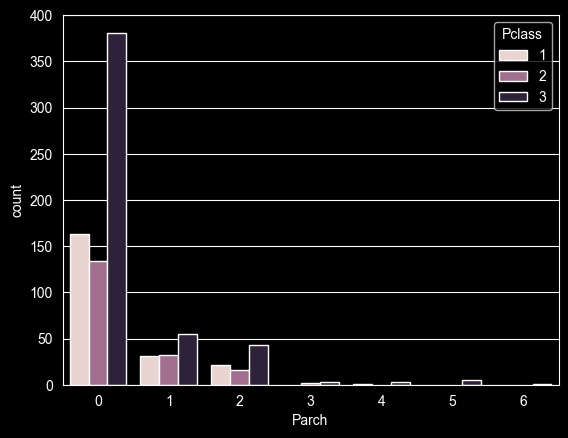

In [332]:
sns.countplot(data=df,x='Parch',hue='Pclass')

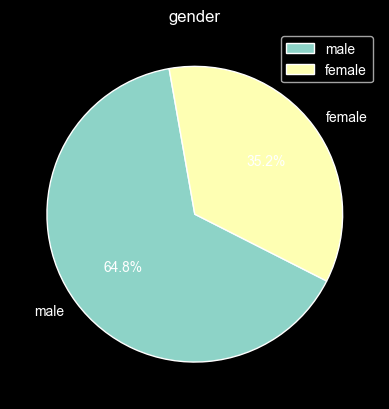

In [333]:
observation_values = list(df["Sex"].value_counts().index)
total_observation_values = list(df["Sex"].value_counts())

plt.pie(total_observation_values,
            labels=observation_values,
            autopct='%1.1f%%',
            startangle=100,
            labeldistance=1.1)
plt.title("gender")
plt.legend()
plt.show()


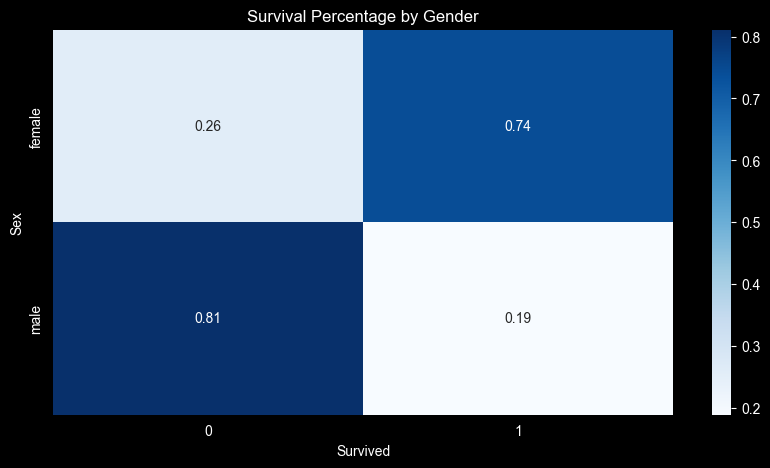

In [334]:
plt.figure(figsize=(10,5))
cross = pd.crosstab(df['Sex'], df['Survived'],normalize='index')

sns.heatmap(cross,annot=True, cmap='Blues')
plt.title("Survival Percentage by Gender");


<Axes: xlabel='Sex'>

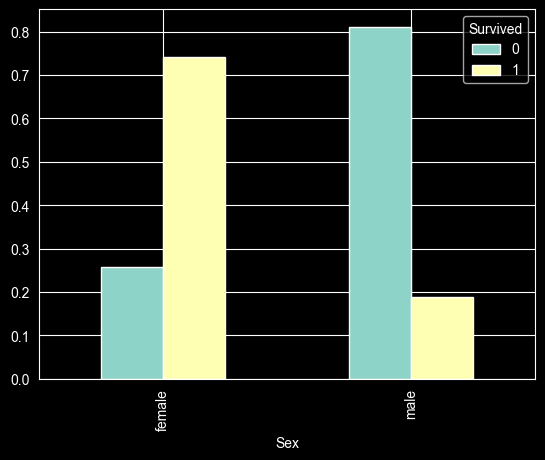

In [335]:
cross.plot(kind='bar')

In [336]:
df['Survived'].value_counts(normalize=True).round(2)

Survived
0    0.62
1    0.38
Name: proportion, dtype: float64

In [337]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

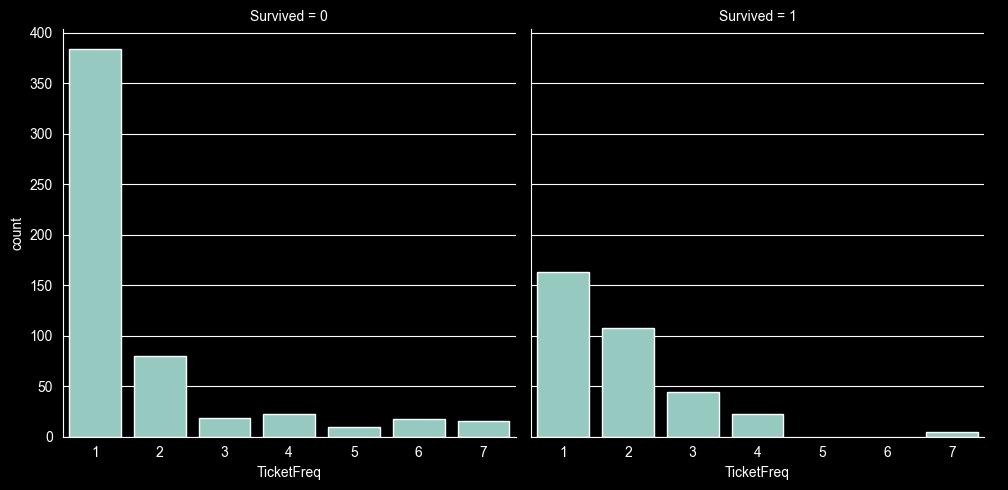

In [338]:
ticket_counts = df['Ticket'].value_counts()

df['TicketFreq'] = df['Ticket'].map(ticket_counts)
sns.catplot(
    data=df,
    x='TicketFreq',
    col='Survived',
    kind='count'
)

In [339]:
df.drop(['Name','PassengerId'],axis=1,inplace=True)

In [340]:
df['Ticket'] = df['Ticket'].str[0]

In [341]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    object 
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Ticket      891 non-null    object 
 7   Fare        891 non-null    float64
 8   Embarked    891 non-null    object 
 9   TicketFreq  891 non-null    int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 69.7+ KB


In [342]:
cat_cols = df.select_dtypes(include='object').columns

In [343]:
df  = pd.get_dummies(df,columns=cat_cols,drop_first=True)

In [344]:
from sklearn.model_selection import train_test_split

In [345]:
891*0.25

222.75

In [346]:
X = df.drop('Survived',axis=1)

In [347]:
y = df['Survived']

In [348]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2 , stratify=y
)

In [349]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [350]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

In [351]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [352]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [353]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [354]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

In [355]:
from sklearn.model_selection import GridSearchCV

In [356]:
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [357]:
log_reg_params = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear']
}

In [358]:
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier())
])

In [359]:
rf_params = {
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__bootstrap': [True, False]
}

In [360]:
log_reg_grid = GridSearchCV(
    log_reg,
    log_reg_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

log_reg_grid.fit(X, y)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l2'], 'model__solver': ['lbfgs', 'liblinear']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [365]:
rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X, y)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'model__bootstrap': [True, False], 'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [364]:
log_reg_grid.best_score_

np.float64(0.8136902893729208)

In [366]:
rf_grid.best_score_

np.float64(0.8294143493817085)

In [367]:
y_pred_rf = rf_grid.predict(X_test)

In [368]:
y_pred_lr = log_reg_grid.predict(X_test)

In [369]:
from sklearn.metrics import classification_report

Logistic Regression Classification Report

In [370]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



RandomForest  Classification Report

In [371]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       110
           1       0.93      0.90      0.91        69

    accuracy                           0.93       179
   macro avg       0.93      0.93      0.93       179
weighted avg       0.93      0.93      0.93       179

